# How many rounds does each lever add?

A paired-seed causal analysis of talent, role fit, language, micro, and the management layer in the deterministic match engine.

## tl;dr

- A normalized 65 team beat an 85 team **7 times in 900 matches (0.8%)**; a normalized 80 team won **27.9%**. The observed concern is real in principle, but not frequent in this controlled engine slice.
- Overall talent is the dominant lever. Micro is the strongest player-skill subsystem: raising the 65 micro bundle to 85 won **5.73 extra rounds per match** in the 75-vs-80 matchup.
- Aligning roles instead of rotating them won **2.83 extra rounds**; restoring role comfort from 40 to 100 won **1.40**. Language was **outcome-inert** in every tested one-match treatment, and no common language defaults to 50.
- With identical 75-overall players, the largest observed management sensitivities included **stamina, halftime talk, tactic aggression**.
- In the fully identical baseline, seed randomness receives **62.2%** of round-margin variance under fair-share interaction attribution; map receives **37.8%**.
- Longer series compound real strength gaps: the 80-vs-85 favorite rises from **72.1% BO1** to **78.9% BO3** and **85.6% BO5**.

## Context & Methods

Each treatment reuses the same map, team-identity swap, and match seed as its comparison level. Effects are therefore within-seed differences, not raw correlations. Confidence intervals cluster the paired differences by seed; three disjoint seed blocks test sign reproducibility. The primary estimand is **rounds won above baseline = treated-team score minus baseline-team score**. We also report **opponent rounds denied = baseline opponent score minus treated opponent score**. Their sum exactly equals the older round-margin improvement. Every comparison names its baseline and treatment explicitly.

Four experiment layers are combined: a broad 65-vs-85 matrix, targeted 65-vs-85 and 75-vs-80 mechanism sweeps, and equal-player 75-vs-75 core and mechanism sweeps. Identity swaps protect against team-id and starting-side artifacts.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
from analysis.match_levers.run_analysis import run_analysis

REPO_ROOT = Path.cwd()
PRIMARY = REPO_ROOT / 'runs/causal-match-20260718-main-e1d9db2/matches.csv'
SUPPLEMENT = REPO_ROOT / 'runs/causal-match-supplement-20260718-e1d9db2/matches.csv'
EQUAL_CORE = REPO_ROOT / 'runs/mcp-experiments/20260718T233618Z-equal-75v75-core/matches.csv'
EQUAL_MECHANISMS = REPO_ROOT / 'runs/mcp-experiments/20260718T233643Z-equal-75v75-mechanisms/matches.csv'
SYMMETRY_BASELINE = REPO_ROOT / 'runs/mcp-experiments/20260719T034402Z-identical-75v75-baseline-300/matches.csv'
IDENTICAL_SERIES = REPO_ROOT / 'runs/mcp-experiments/20260719T035909Z-identical-series-bo3-bo5-300/series.csv'
OUTPUT = REPO_ROOT / 'analysis/match_levers/output'

from analysis.match_levers.variance_decomposition import run_decomposition
from analysis.match_levers.series_analysis import run_series_analysis
summary = run_analysis(PRIMARY, SUPPLEMENT, EQUAL_CORE, EQUAL_MECHANISMS, OUTPUT)
variance_summary = run_decomposition(PRIMARY, EQUAL_CORE, SYMMETRY_BASELINE, OUTPUT)
series_summary = run_series_analysis(PRIMARY, SUPPLEMENT, IDENTICAL_SERIES, OUTPUT)
print(f"Analyzed {summary['total_matches']:,} deterministic matches.")

Analyzed 189,450 deterministic matches.


## Data

In [2]:
quality = pd.read_csv(OUTPUT / 'tables/data_quality.csv')
assert (quality['duplicate_pairing_rows'] == 0).all()
display(quality)

,source,rows,cells,contexts,factors,maps,seed_blocks,duplicate_pairing_rows
0,primary,103500,3450,2,32,5,3,0
1,supplement,45000,1500,2,7,5,3,0
2,equal_core,33750,2250,1,20,5,3,0
3,equal_mechanisms,7200,480,1,4,5,3,0


All datasets must have complete causal keys before interpretation. The two main sweeps use 90 unique seeds per treatment level; equal-player supplements use 45, each repeated over five maps and both identity swaps. The symmetry baseline adds 300 unique map-seed matches across 60 seeds.

## Results

### 1. Overall talent is the dominant match lever

,weak_overall,matches,wins,win_rate,win_ci_low,win_ci_high,mean_round_margin,close_match_rate
0,45.0,900,0,0.00,-0.00,0.43,-12.274,0.00
1,55.0,900,0,0.00,-0.00,0.43,-11.340,0.00
2,65.0,900,7,0.78,0.38,1.60,-9.543,1.78
3,70.0,900,17,1.89,1.18,3.00,-8.136,5.56
4,75.0,900,92,10.22,8.41,12.37,-5.999,10.67
5,80.0,900,251,27.89,25.06,30.91,-3.176,20.22
6,85.0,900,450,50.00,46.74,53.26,0.000,21.78


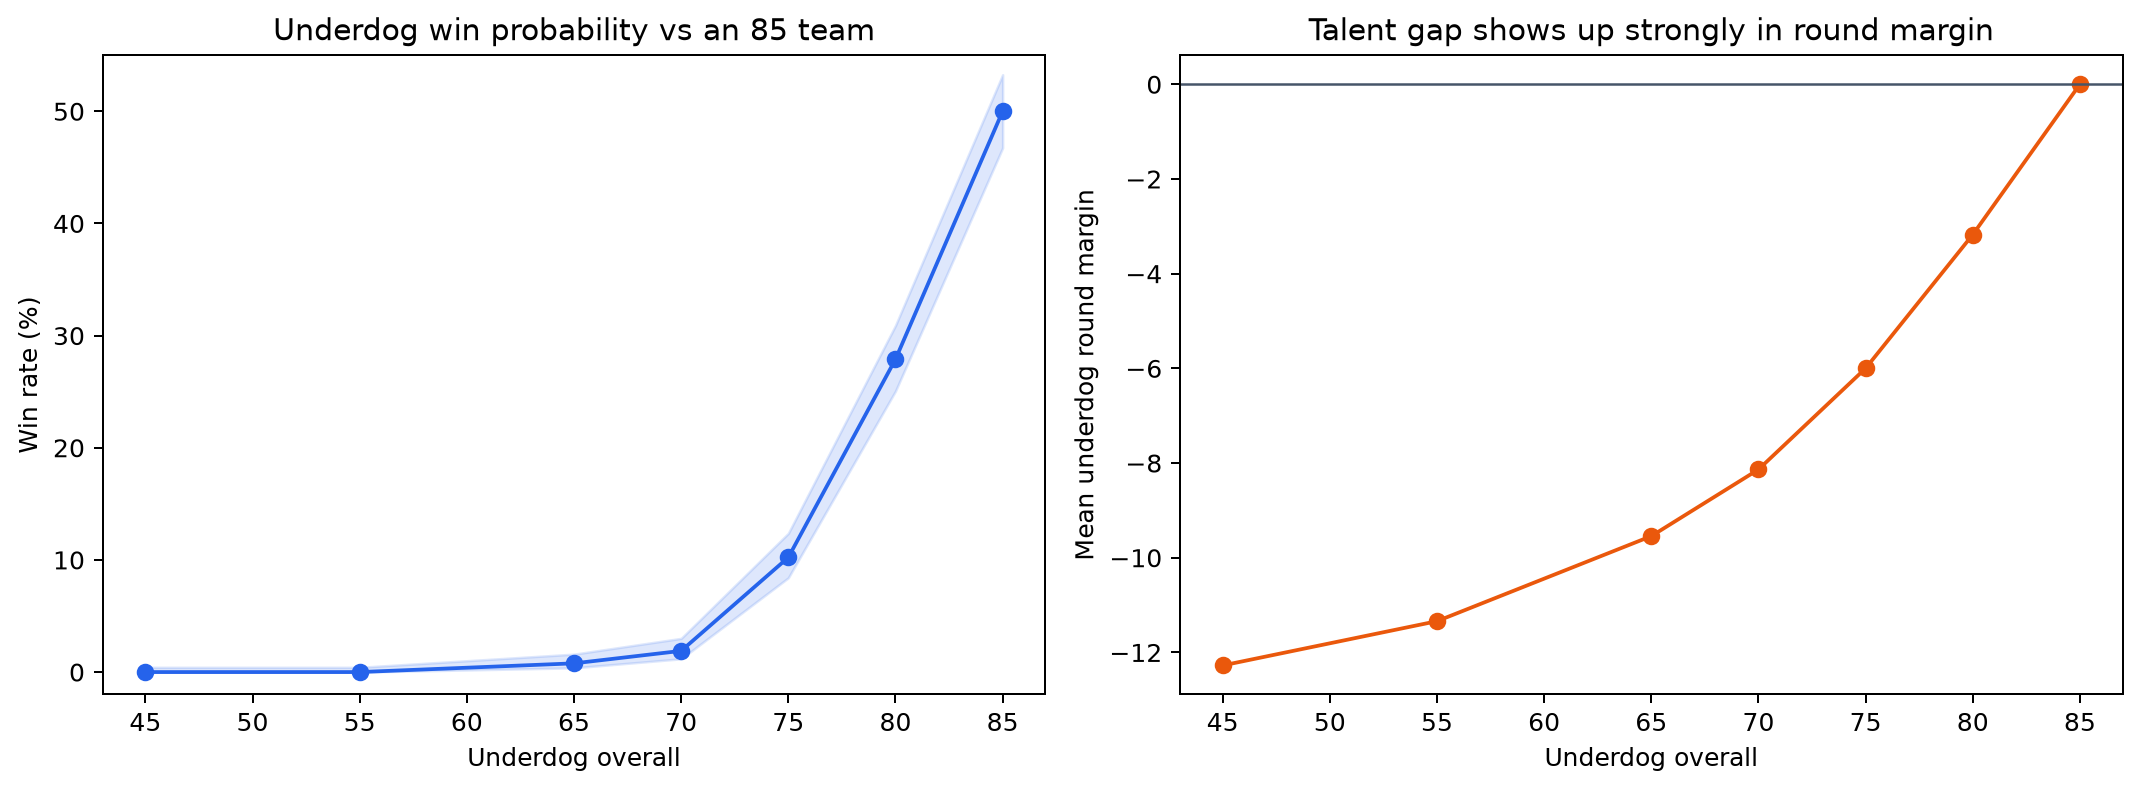

In [3]:
curve = pd.read_csv(OUTPUT / 'tables/overall_curve.csv')
curve_view = curve.copy()
for col in ['win_rate','win_ci_low','win_ci_high','close_match_rate']: curve_view[col] = (curve_view[col] * 100).round(2)
display(curve_view.round(3))
display(Image(filename=str(OUTPUT / 'figures/overall_curve.png')))

Win probability is intentionally nonlinear: the 65-vs-85 matchup is almost closed, while moving from 75 to 80 buys much more probability. The treatment team's rounds won remains interpretable even when win rate is floored near zero.

### 2. Micro, role fit, language, and IGL experience

,context,lever,low_level,high_level,rounds_won_added,rounds_won_added_ci_low,rounds_won_added_ci_high,opponent_rounds_denied,weak_round_margin_effect,win_effect_pp,seed_block_sign_agreement
0,normalized_65v85,Aim precision 65 to 85,65,85,2.467,2.271,2.662,0.233,2.700,6.444,100.000
1,normalized_65v85,Aim reactivity 65 to 85,65,85,2.072,1.864,2.280,0.107,2.179,4.778,100.000
2,normalized_65v85,Movement 65 to 85,65,85,0.464,0.281,0.648,0.030,0.494,1.222,100.000
3,normalized_65v85_supplement,Micro bundle 65 to 85,65,85,5.494,5.258,5.731,1.278,6.772,30.333,100.000
4,normalized_75v80_supplement,Micro bundle 65 to 85,65,85,5.728,5.444,6.011,3.188,8.916,55.778,100.000
5,normalized_65v85_supplement,Role comfort,40,100,0.832,0.668,0.996,0.007,0.839,0.556,100.000
6,normalized_75v80_supplement,Role comfort,40,100,1.399,1.194,1.604,0.547,1.946,10.667,100.000
7,normalized_65v85_supplement,Aligned roles vs rotated,rotated,aligned,3.602,3.354,3.851,0.619,4.221,16.222,100.000
8,normalized_75v80_supplement,Aligned roles vs rotated,rotated,aligned,2.831,2.586,3.076,3.164,5.996,43.111,100.000
9,normalized_65v85_supplement,Language 50 to 100,50,100,0.000,0.000,0.000,-0.000,0.000,0.000,100.000


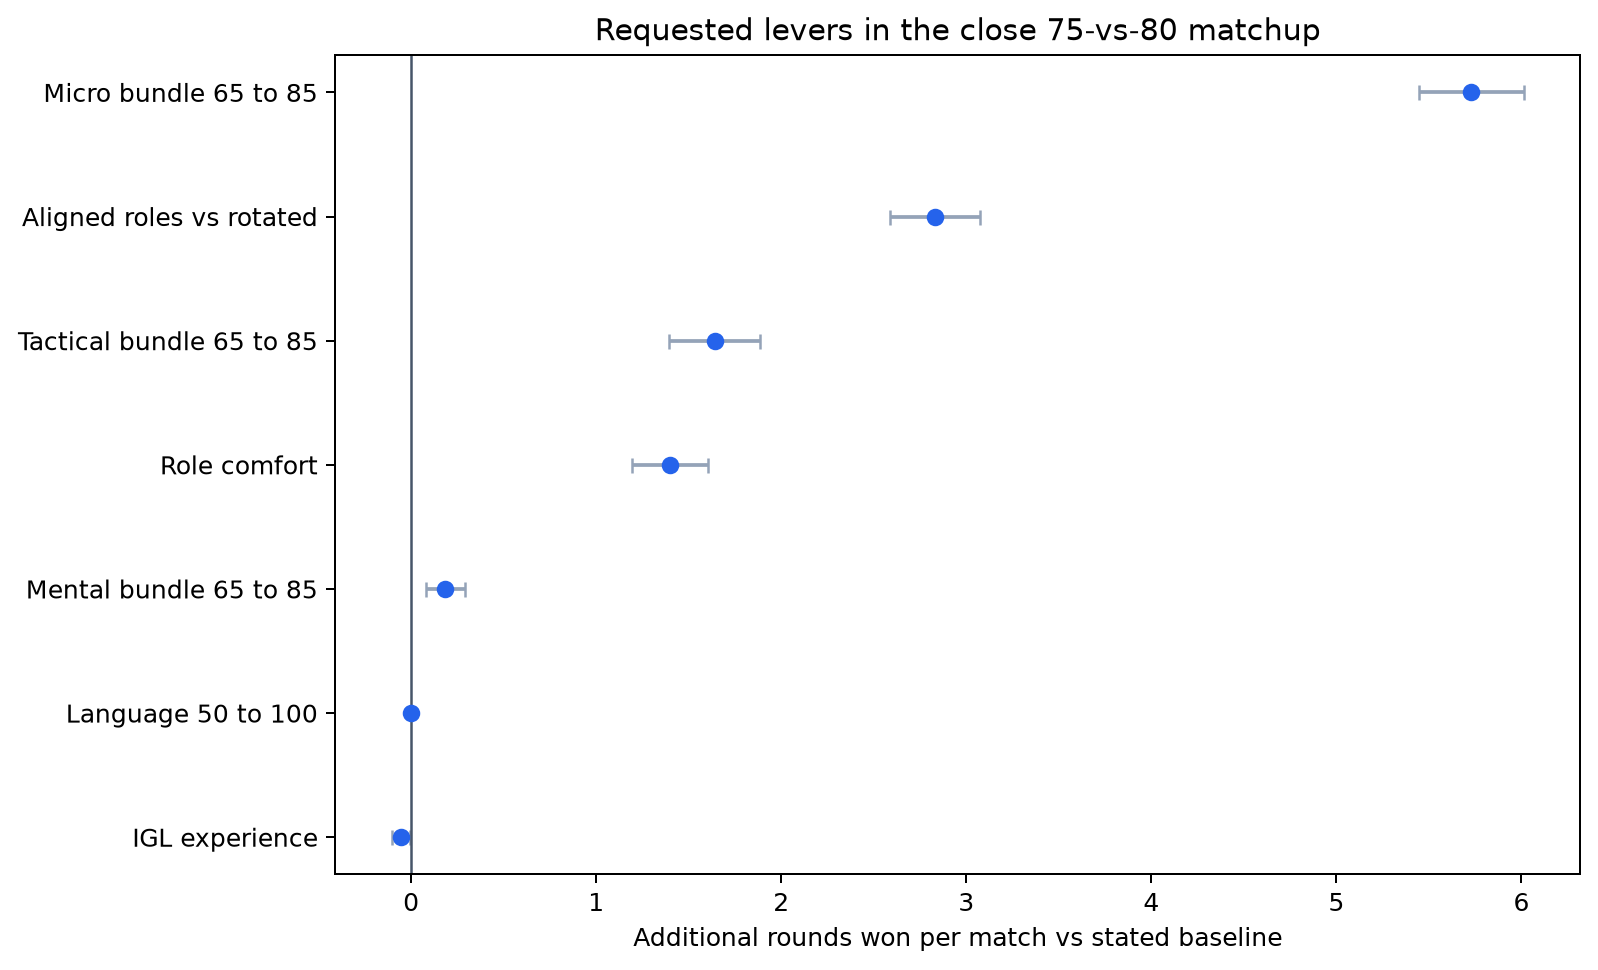

In [4]:
requested = pd.read_csv(OUTPUT / 'tables/requested_levers_with_equivalents.csv')
cols = ['context','lever','low_level','high_level','rounds_won_added','rounds_won_added_ci_low','rounds_won_added_ci_high','opponent_rounds_denied','weak_round_margin_effect','win_effect_pp','seed_block_sign_agreement']
requested_view = requested[cols].copy()
requested_view['seed_block_sign_agreement'] *= 100
display(requested_view.round(3))
display(Image(filename=str(OUTPUT / 'figures/requested_levers_close_gap.png')))

In [5]:
mechanisms = pd.read_csv(OUTPUT / 'tables/mechanism_levels.csv')
role_detail = mechanisms[mechanisms['factor'].isin(['role_comfort','role_assignment'])]
role_view = role_detail[['context','factor','level','effective_weak_quality','weak_win_rate','mean_weak_round_margin']].copy()
role_view['weak_win_rate'] *= 100
display(role_view.round(3))

,context,factor,level,effective_weak_quality,weak_win_rate,mean_weak_round_margin
10,normalized_65v85_supplement,role_assignment,aligned,75.556,18.667,-4.433
11,normalized_65v85_supplement,role_assignment,rotated,65.000,2.444,-8.654
12,normalized_65v85_supplement,role_assignment,worst_fit,61.500,0.667,-9.790
13,normalized_65v85_supplement,role_comfort,100,65.000,0.889,-9.409
14,normalized_65v85_supplement,role_comfort,40,61.400,0.333,-10.248
15,normalized_65v85_supplement,role_comfort,60,62.600,0.444,-9.996
16,normalized_65v85_supplement,role_comfort,80,63.800,0.667,-9.798
35,normalized_75v80_supplement,role_assignment,aligned,85.043,79.111,4.238
36,normalized_75v80_supplement,role_assignment,rotated,74.948,36.000,-1.758
37,normalized_75v80_supplement,role_assignment,worst_fit,71.500,24.222,-3.747


Read each row as: changing the stated baseline level to the treatment level wins `rounds_won_added` more rounds per match on average. `opponent_rounds_denied` is separate; adding the two reproduces `weak_round_margin_effect`. Role assignment combines weighted skill-role fit and effective-ability consequences; role comfort isolates the campaign unfamiliarity penalty.

In [6]:
language_check = summary['language_no_common_equals_shared_50']
display(pd.DataFrame(language_check).T)

,paired_matches,identical_winner_and_score,all_tested_levels_identical
normalized_65v85_supplement,900,True,True
normalized_75v80_supplement,900,True,True


The exact equality above is only part of the finding: all tested fluency levels from 20 through 100 also produced byte-identical scores and winners. The comms model calculates language-adjusted recall, but these treatments never crossed a decision threshold under the current policy. When teammates have no common tongue, `_language_overlap` additionally defaults to 50. Longer-term language effects through relationships and chemistry are outside this direct estimate.

### 3. Management leverage with identical players

,context,factor,baseline_level,treatment_level,rounds_won_added,rounds_won_added_ci_low,rounds_won_added_ci_high,opponent_rounds_denied,weak_round_margin_effect,weak_win_effect_pp,seed_block_sign_agreement
29,equal_75v75_core,stamina,100,40,-1.716,-2.023,-1.408,-1.218,-2.933,-19.333,100.0
20,equal_75v75_core,halftime_talk,none,demand_more,-1.678,-2.118,-1.238,-1.142,-2.820,-17.778,100.0
32,equal_75v75_core,tactic_aggression,50,100,1.516,1.205,1.826,1.944,3.460,23.333,100.0
58,equal_75v75_mechanisms,role_assignment,rotated,aligned,1.513,1.295,1.732,3.333,4.847,29.333,100.0
6,equal_75v75_core,chemistry_complex_system,65,20,-1.153,-1.400,-0.906,-0.824,-1.978,-14.000,100.0
60,equal_75v75_mechanisms,role_comfort,100,40,-1.096,-1.396,-0.795,-1.002,-2.098,-16.444,100.0
18,equal_75v75_core,form,50,80,1.033,0.820,1.247,0.953,1.987,14.889,100.0
59,equal_75v75_mechanisms,role_assignment,rotated,worst_fit,-1.004,-1.386,-0.623,-1.373,-2.378,-17.778,100.0
17,equal_75v75_core,form,50,20,-0.953,-1.216,-0.691,-1.033,-1.987,-14.889,100.0
34,equal_75v75_core,tactic_aggression,50,75,0.864,0.536,1.193,1.211,2.076,13.778,100.0


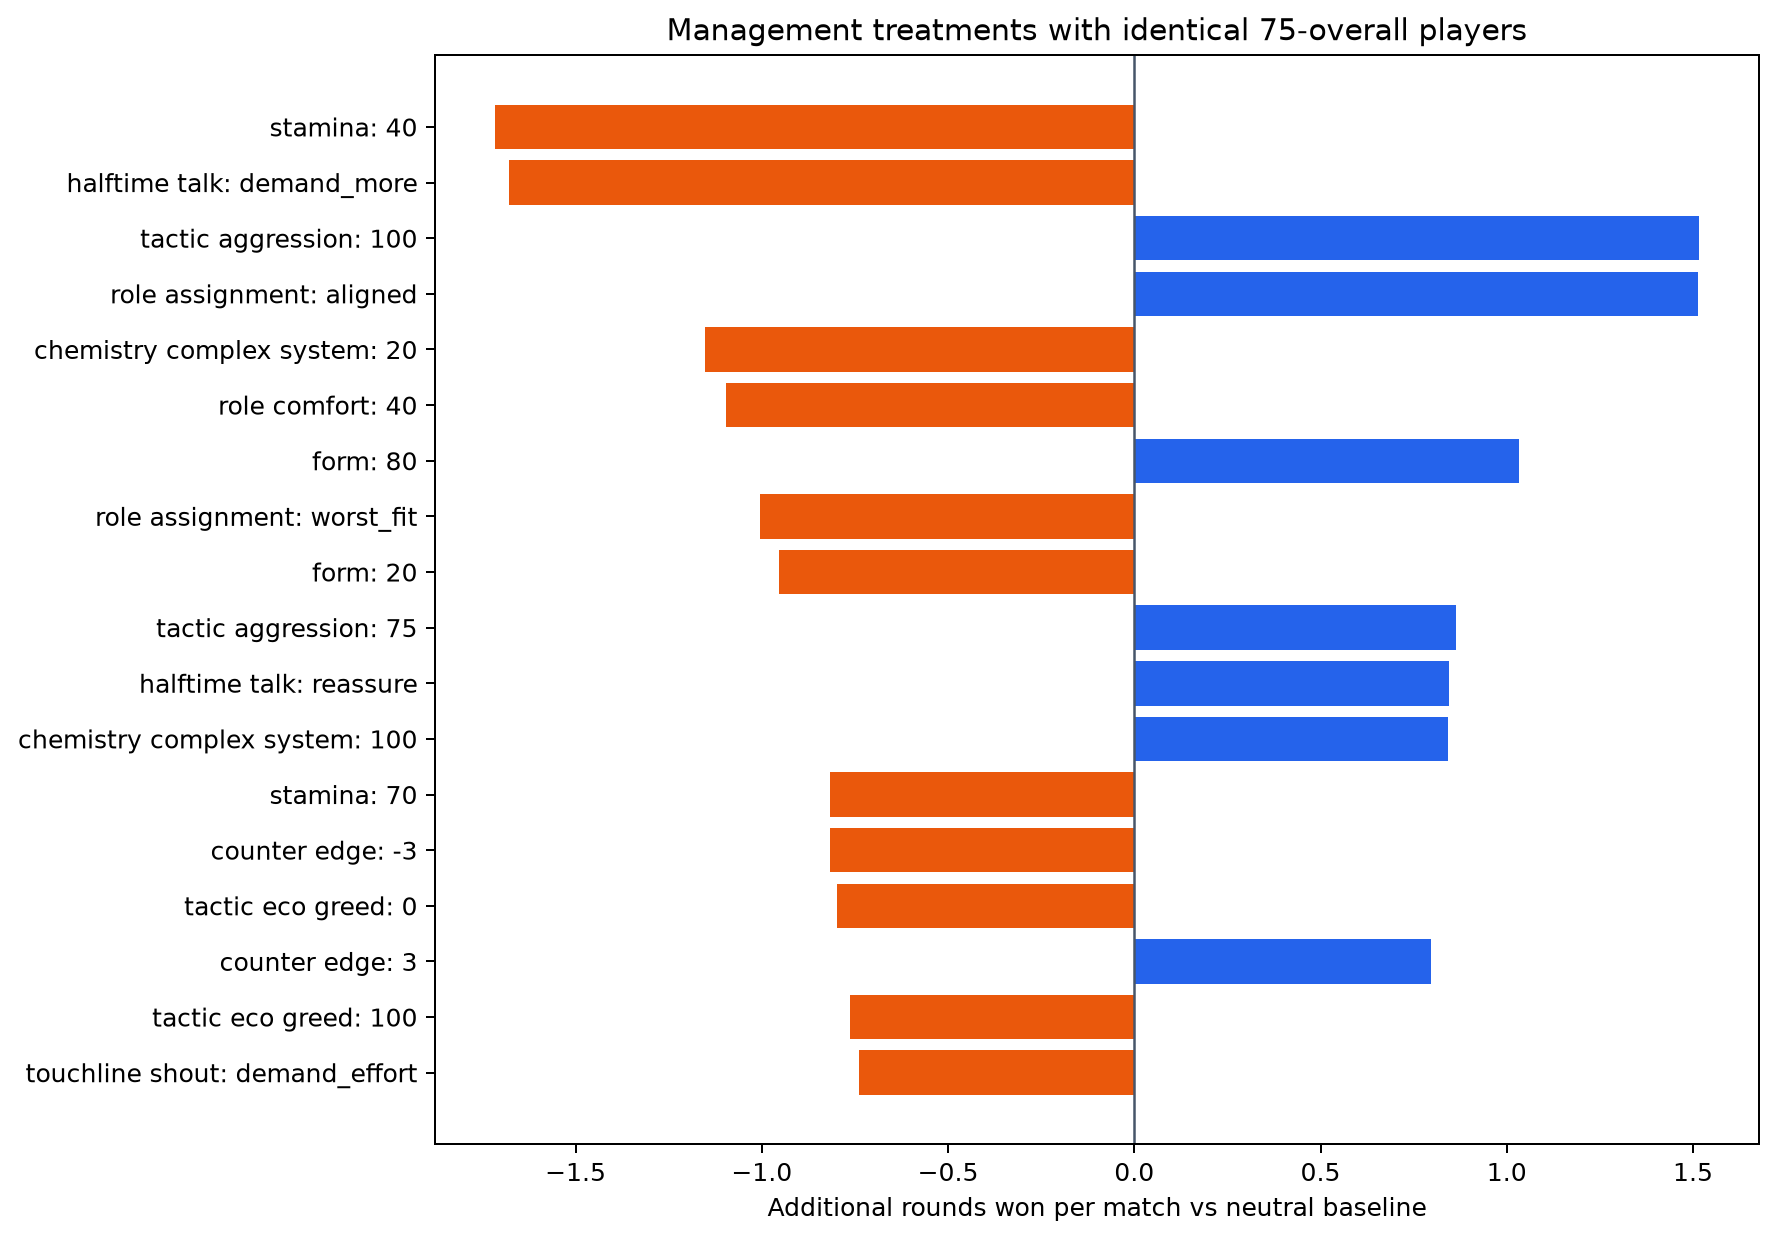

In [7]:
effects = pd.read_csv(OUTPUT / 'tables/baseline_rounds_added.csv')
equal = effects[effects['context'].str.startswith('equal_75v75')].copy()
equal['absolute_effect'] = equal['rounds_won_added'].abs()
equal_view = equal.sort_values('absolute_effect', ascending=False).head(20)[['context','factor','baseline_level','treatment_level','rounds_won_added','rounds_won_added_ci_low','rounds_won_added_ci_high','opponent_rounds_denied','weak_round_margin_effect','weak_win_effect_pp','seed_block_sign_agreement']].copy()
equal_view['seed_block_sign_agreement'] *= 100
display(equal_view.round(3))
display(Image(filename=str(OUTPUT / 'figures/equal_talent_management.png')))

Every row now compares with a predeclared neutral baseline: tactics use 50, counter-strat uses 0, prep uses 0, halftime/touchline choices use none, and role assignment uses rotated. Tactics remain directional identities, not universal quality sliders; a positive treatment effect in this matchup is not proof that the same endpoint is globally optimal.

### 4. Reproducibility across seed blocks

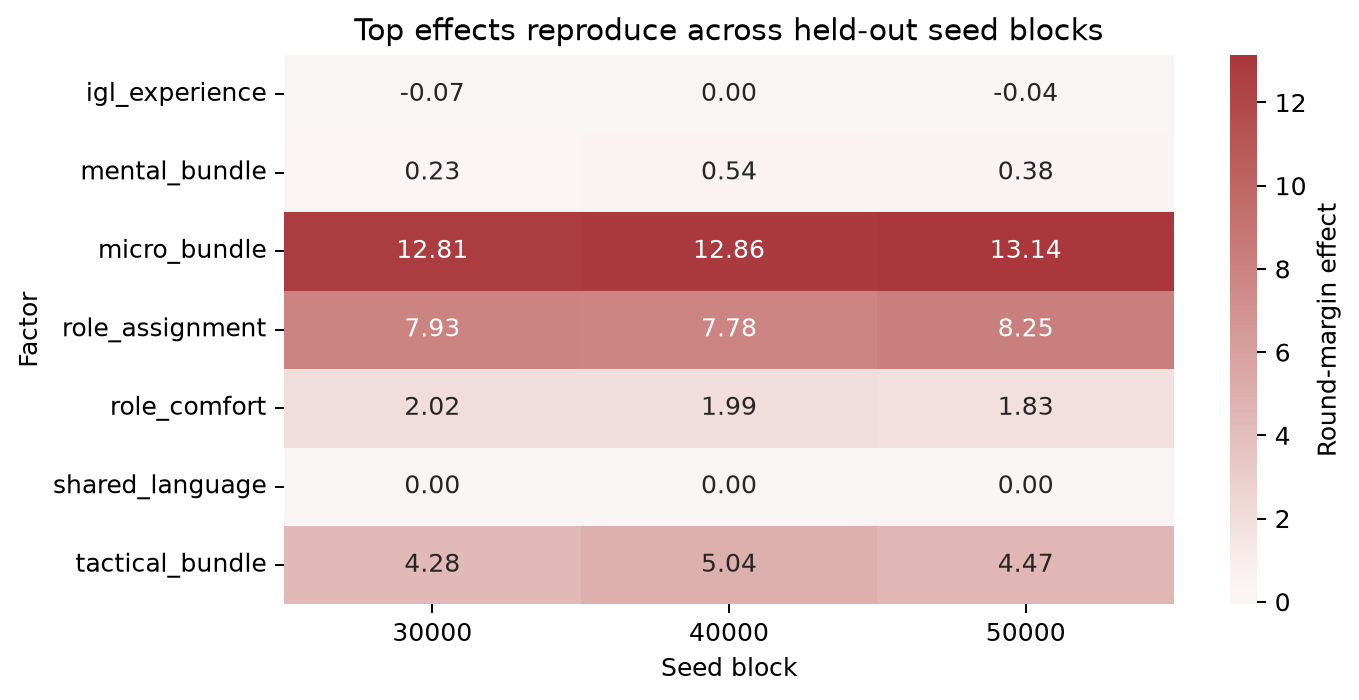

,context,factor,seed_block,effect
0,normalized_75v80_supplement,micro_bundle,30000,12.806667
1,normalized_75v80_supplement,micro_bundle,40000,12.856667
2,normalized_75v80_supplement,micro_bundle,50000,13.136667
3,normalized_65v85,weak_overall,0,12.246667
4,normalized_65v85,weak_overall,10000,12.226667
5,normalized_65v85,weak_overall,20000,12.350000
6,normalized_65v85_supplement,micro_bundle,30000,9.300000
7,normalized_65v85_supplement,micro_bundle,40000,9.533333
8,normalized_65v85_supplement,micro_bundle,50000,8.863333
9,normalized_75v80_supplement,role_assignment,30000,7.926667


In [8]:
display(Image(filename=str(OUTPUT / 'figures/seed_block_robustness.png')))
robust = pd.read_csv(OUTPUT / 'tables/seed_block_robustness.csv')
display(robust.head(24))

### 5. What actually drives match-to-match variance

,dataset,component,component_label,fair_share_pct,direct_main_pct,total_effect_pct
0,Broad 65-vs-85 lever sweep,version_id,Treatment configuration,24.217,15.333,43.718
1,Broad 65-vs-85 lever sweep,map_id,Map,24.360,0.840,67.079
2,Broad 65-vs-85 lever sweep,identity_swap,Stable identity / orientation,19.671,2.184,54.052
3,Broad 65-vs-85 lever sweep,seed,Seed randomness,31.751,3.113,80.592
4,Equal-player management sweep,version_id,Treatment configuration,10.808,2.972,27.881
5,Equal-player management sweep,map_id,Map,25.637,0.002,79.113
6,Equal-player management sweep,identity_swap,Stable identity / orientation,30.223,0.572,85.850
7,Equal-player management sweep,seed,Seed randomness,33.332,0.055,95.298
8,Identical 75-vs-75 baseline,map_id,Map,37.817,1.816,73.818
9,Identical 75-vs-75 baseline,seed,Seed randomness,62.183,26.182,98.184


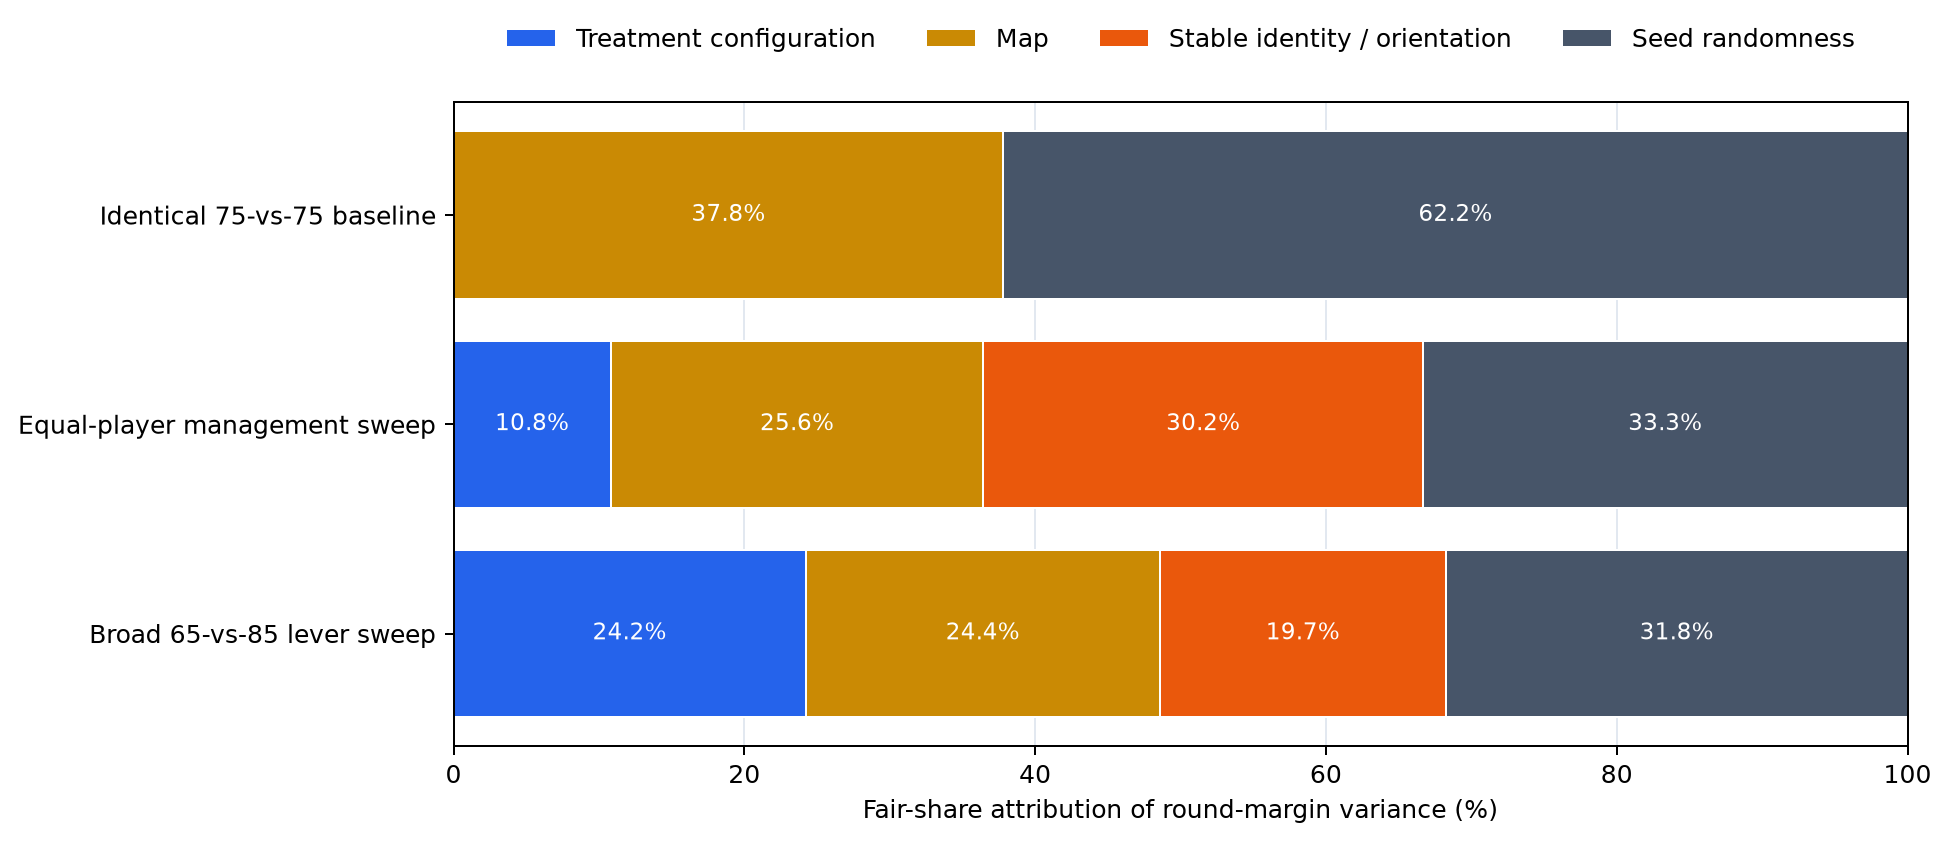

,dataset,family,versions,share_of_direct_treatment_pct,share_of_total_variance_pct
0,Broad 65-vs-85 lever sweep,Overall talent,7,81.519,12.499
1,Broad 65-vs-85 lever sweep,Player mechanics / role,33,9.100,1.395
2,Broad 65-vs-85 lever sweep,Readiness / mastery,20,2.500,0.383
3,Broad 65-vs-85 lever sweep,Strategy / management,55,6.881,1.055
4,Equal-player management sweep,Readiness / mastery,20,32.469,0.965
5,Equal-player management sweep,Strategy / management,55,67.531,2.007


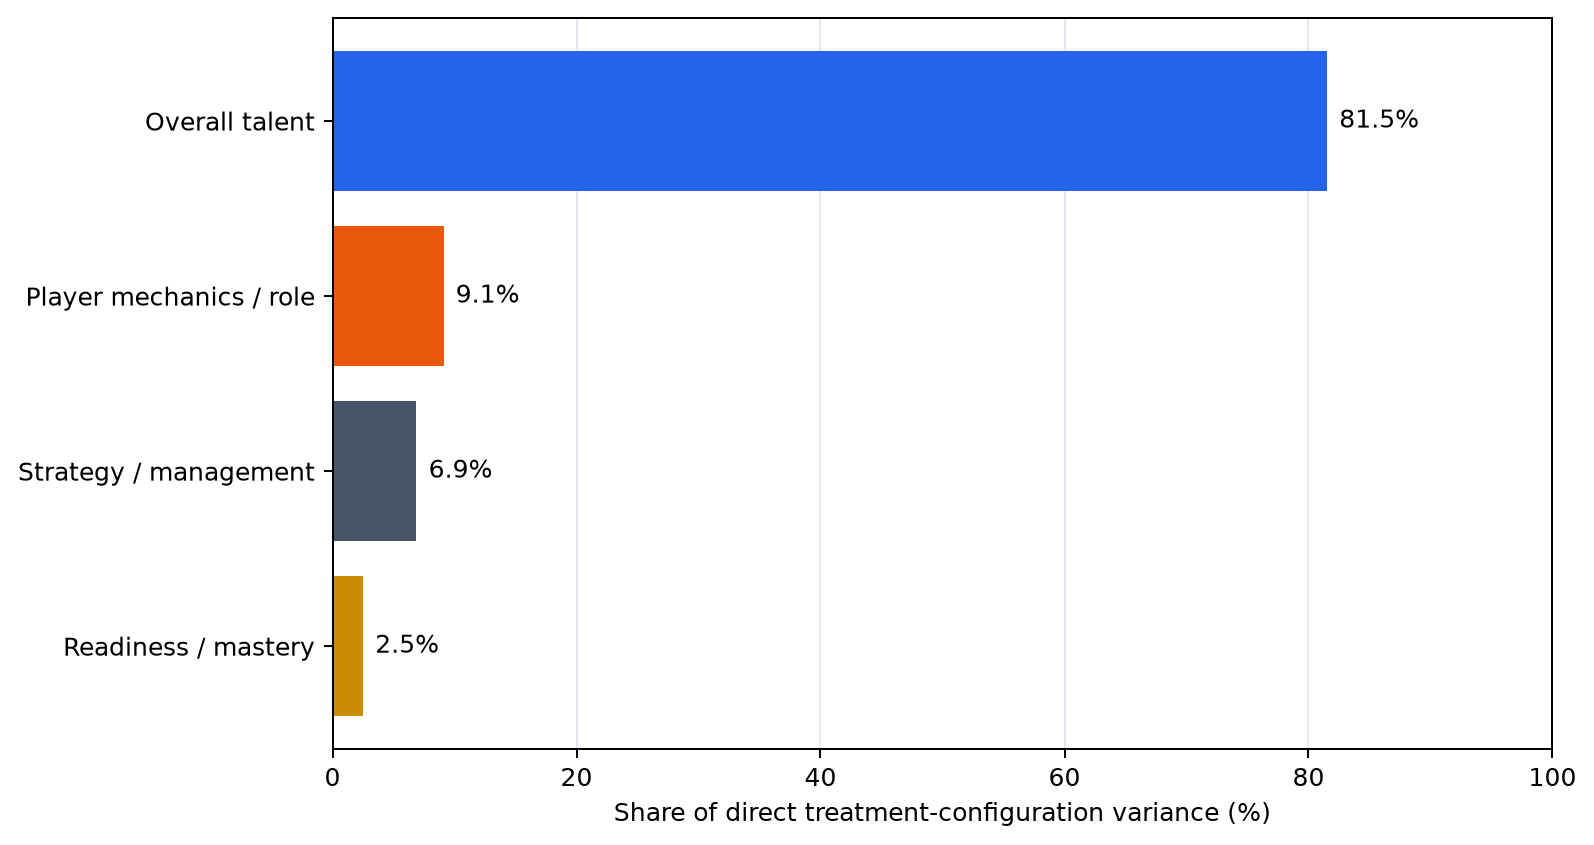

In [9]:
variance = pd.read_csv(OUTPUT / 'tables/variance_decomposition.csv')
display(variance.round(3))
display(Image(filename=str(OUTPUT / 'figures/variance_decomposition.png')))
families = pd.read_csv(OUTPUT / 'tables/treatment_family_decomposition.csv')
display(families.round(3))
display(Image(filename=str(OUTPUT / 'figures/treatment_family_decomposition.png')))

The fair-share numbers use a balanced functional ANOVA. Every interaction is split equally among the factors participating in it, so the displayed shares sum to 100%. In the exact symmetry baseline, seed receives 62.2% and map 37.8%. In the broad lever sweep, seed remains the largest component at 31.8%, while treatment configuration receives 24.2%. This does **not** mean some seed numbers are universally good: 72.0% of baseline variance is a map-by-seed interaction.

### 6. Longer series filter upsets, not fairness

,matchup,format,team_role,win_rate,ci_low,ci_high,underdog_win_rate,series_rows,seed_clusters
0,65 vs 85,BO1,favorite,0.9922,0.9866,0.9979,0.0078,900,90
1,65 vs 85,BO3,favorite,1.0000,1.0000,1.0000,0.0000,180,90
2,65 vs 85,BO5,favorite,1.0000,1.0000,1.0000,0.0000,180,90
3,75 vs 85,BO1,favorite,0.8978,0.8818,0.9138,0.1022,900,90
4,75 vs 85,BO3,favorite,0.9833,0.9644,1.0000,0.0167,180,90
5,75 vs 85,BO5,favorite,0.9944,0.9834,1.0000,0.0056,180,90
6,80 vs 85,BO1,favorite,0.7211,0.6947,0.7475,0.2789,900,90
7,80 vs 85,BO3,favorite,0.7889,0.7323,0.8454,0.2111,180,90
8,80 vs 85,BO5,favorite,0.8556,0.8053,0.9058,0.1444,180,90
9,75 vs 80,BO1,favorite,0.7322,0.7060,0.7585,0.2678,900,90


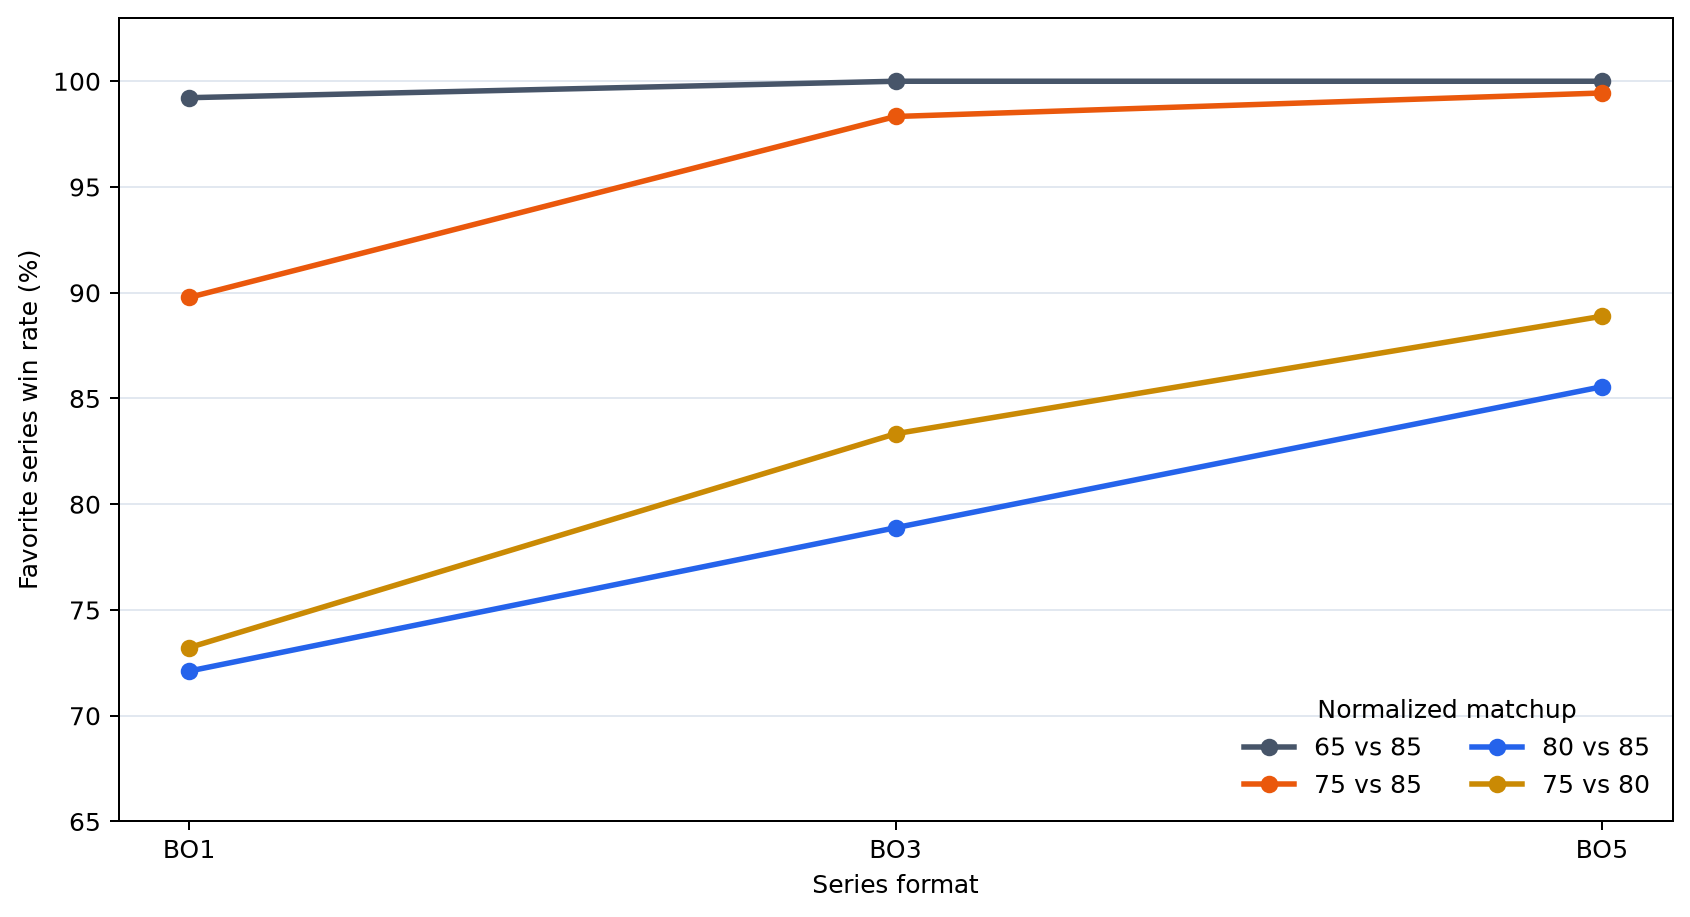

In [10]:
series_rates = pd.read_csv(OUTPUT / 'tables/series_format_win_rates.csv')
display(series_rates.round(4))
display(Image(filename=str(OUTPUT / 'figures/series_format_favorite_win_rates.png')))

Identical teams stayed fair: the designated team won 49.3% of 300 BO3s and 49.0% of 300 BO5s. Longer formats instead amplify real strength differences. An 80-vs-85 favorite increased from 72.1% in BO1 to 78.9% in BO3 and 85.6% in BO5; a 75-vs-80 favorite increased from 73.2% to 83.3% to 88.9%. The BO3 and BO5 winner differed on 19.0% of identical-team paired seeds, so additional maps do not remove randomness—they average more of it.

## Takeaways

1. **Do not globally increase favorite strength yet.** The controlled 65-vs-85 upset rate is below 1%; use production-save telemetry to see whether authored rosters, form, or management bonuses are creating a different distribution.
2. **Treat micro as the main player-level tuning surface.** Aim precision and reactivity explain much more than comms/composure in the direct match layer.
3. **Calibrate assignment-weighted role fit.** Specialized aligned attributes currently gain a large effective-rating premium; comfort penalties are already bounded and behave more predictably.
4. **Make language behavior observable.** Review both the neutral no-common fallback and the downstream recall thresholds; the current one-match result is identical from 20 to 100 fluency.
5. **Use the equal-player suite for strategy tuning.** It identifies prep, counter-strat, tactics, chemistry, coaching, agent/map mastery, language, IGL, and assignments without player talent drowning out the signal.
6. **Keep meaningful randomness, but measure it as an interaction.** Seeds contribute strongly to single-match outcomes, primarily by changing what happens on a particular map and identity orientation rather than providing a universal bias.
7. **Balance around series format.** BO3 already protects moderate favorites; BO5 makes a five-point talent edge win roughly 86-89% of normalized series.

Further work: repeat the top categorical configurations on held-out seeds, add campaign-generated scouting accuracy as an explicit treatment, and compare these normalized teams with authored roster distributions.